### Importing Libraries

In [29]:
import numpy as np
import pandas as pd
import math

import datetime as dt
from datetime import date

import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
plt.ion()
sns.set()

import sklearn
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn import utils

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from keras_tuner.tuners import RandomSearch
from tensorflow.keras.layers import Dense, Dropout, LSTM, Activation, Input
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard

import warnings
warnings.filterwarnings('ignore')

import gc
gc.collect()

7249

### Loading the Data

In [30]:
## Loading the data from a csv file
data = pd.read_csv(r"d:\Shafqat\Stock-Market-Prediction-Portfolio-Optimization-main\Data\Stocks (part of the experimental set)\Habib Bank Stock Price History.csv")
data.rename(columns={'Price': 'Close'}, inplace=True)
for col in ['Open', 'High', 'Low', 'Close']:
    data[col] = pd.to_numeric(data[col], errors='coerce')
data = data.drop(columns=[c for c in ['Vol.', 'Change %'] if c in data.columns], errors='ignore')
data['Date'] = pd.to_datetime(data['Date'], dayfirst=False, errors='coerce')
data = data.dropna(subset=['Date', 'Open', 'High', 'Low', 'Close'])

data = data.sort_values('Date').reset_index(drop=True)
data

,Date,Close,Open,High,Low
0,2016-05-01,175.50,190.79,204.00,174.00
1,2016-06-01,197.00,175.89,213.50,170.01
2,2016-07-01,216.51,199.00,224.20,194.00
3,2016-08-01,217.10,218.50,226.30,212.40
4,2016-09-01,221.00,217.49,231.85,215.01
...,...,...,...,...,...
115,2025-12-01,323.41,309.30,332.10,304.03
116,2026-01-01,343.90,322.00,369.99,322.00
117,2026-02-01,310.54,345.00,347.49,292.55
118,2026-03-01,248.59,279.49,295.00,235.55


### Technical Indicator Features

In [31]:
## Indicator helper functions
def sma(series, length):
    return series.rolling(window=length, min_periods=1).mean()

def ema(series, length):
    return series.ewm(span=length, adjust=False).mean()

def dema(series, length):
    ema1 = ema(series, length)
    ema2 = ema(ema1, length)
    return 2 * ema1 - ema2

def tema(series, length):
    ema1 = ema(series, length)
    ema2 = ema(ema1, length)
    ema3 = ema(ema2, length)
    return 3 * ema1 - 3 * ema2 + ema3

def kama(series, length):
    change = series.diff(length).abs()
    volatility = series.diff().abs().rolling(length, min_periods=1).sum()
    er = change / volatility.replace(0, np.nan)
    fast = 2 / (2 + 1)
    slow = 2 / (30 + 1)
    sc = (er * (fast - slow) + slow) ** 2
    kama_series = pd.Series(np.nan, index=series.index)
    kama_series.iloc[:length] = series.iloc[:length]
    for i in range(length, len(series)):
        kama_series.iloc[i] = kama_series.iloc[i - 1] + sc.iloc[i] * (series.iloc[i] - kama_series.iloc[i - 1])
    return kama_series

## Simple Moving Average
for label, length in [('F', 21), ('M', 75), ('S', 150)]:
    data[f'SMA Close ({label})'] = sma(data['Close'], length)

## Exponential Moving Average
for label, length in [('F', 21), ('M', 75), ('S', 150)]:
    data[f'EMA Close ({label})'] = ema(data['Close'], length)

## Double Exponential Moving Average
for label, length in [('F', 21), ('M', 75), ('S', 150)]:
    data[f'DEMA Close ({label})'] = dema(data['Close'], length)

## Triple Exponential Moving Average
for label, length in [('F', 21), ('M', 75), ('S', 150)]:
    data[f'TEMA Close ({label})'] = tema(data['Close'], length)

## Kaufman Adaptive Moving Average
for label, length in [('F', 21), ('M', 75), ('S', 150)]:
    data[f'KAMA Close ({label})'] = kama(data['Close'], length)

## MACD
ema12 = ema(data['Close'], 12)
ema26 = ema(data['Close'], 26)
macdClose = ema12 - ema26
signalClose = ema(macdClose, 9)

## Bollinger Bands (length 5, std 2)
mid_band = sma(data['Close'], 5)
std_band = data['Close'].rolling(window=5, min_periods=1).std()
upper_band = mid_band + 2 * std_band
lower_band = mid_band - 2 * std_band
bandwidth = (upper_band - lower_band) / mid_band
percent_band = (data['Close'] - lower_band) / (upper_band - lower_band)

## Momentum
momentum = data['Close'] - data['Close'].shift(10)

## Relative Strength Index

delta = data['Close'].diff()
gain = delta.where(delta > 0, 0.0)
loss = -delta.where(delta < 0, 0.0)
avg_gain = gain.rolling(window=14, min_periods=1).mean()
avg_loss = loss.rolling(window=14, min_periods=1).mean()
rs = avg_gain / avg_loss.replace(0, np.nan)
rsi_close = 100 - (100 / (1 + rs))

## True Range and ATR
tr1 = data['High'] - data['Low']
tr2 = (data['High'] - data['Close'].shift(1)).abs()
tr3 = (data['Low'] - data['Close'].shift(1)).abs()
true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
atr = true_range.rolling(window=14, min_periods=1).mean()

## Assign computed indicator columns
for label, value in [('BBL_5_2.0', lower_band), ('BBM_5_2.0', mid_band), ('BBU_5_2.0', upper_band),
                     ('BBB_5_2.0', bandwidth), ('BBP_5_2.0', percent_band)]:
    data[label] = value

for label, value in [('MACDClose', macdClose), ('HistClose', macdClose - signalClose), ('SignalClose', signalClose)]:
    data[label] = value

data['Momentum Close'] = momentum
data['RSI Close'] = rsi_close
data['TrueRange'] = true_range
data['AvgTrueRange'] = atr

bbandsClose = pd.DataFrame({
    'BBL_5_2.0': lower_band,
    'BBM_5_2.0': mid_band,
    'BBU_5_2.0': upper_band,
    'BBB_5_2.0': bandwidth,
    'BBP_5_2.0': percent_band
})

macdClose = pd.DataFrame({
    'MACD_12_26_9': macdClose,
    'MACDh_12_26_9': macdClose - signalClose,
    'MACDs_12_26_9': signalClose
})

In [32]:
bbandsCloseNames= {'BBL_5_2.0' : 'CloseLower', 
                   'BBM_5_2.0' : 'CloseMid', 
                   'BBU_5_2.0' : 'CloseUpper', 
                   'BBB_5_2.0' : 'CloseBandwidth', 
                   'BBP_5_2.0' : 'Close%Columns'}

for i in bbandsClose.columns:
    data[i]= bbandsClose[i]
data.rename(columns= bbandsCloseNames, inplace= True)

In [33]:
macdCloseNames= {'MACD_12_26_9': 'MACDClose', 
                 'MACDh_12_26_9': 'HistClose', 
                 'MACDs_12_26_9': 'SignalClose'}

for i in macdClose.columns:
    data[i]= macdClose[i]
data.rename(columns= macdCloseNames, inplace= True)

### Return Features

In [34]:
## Simple Return
data['CloseR']= data['Close']/data['Close'].shift(-1) ## target feature we want to predict
data['OpenR']= data['Open']/data['Open'].shift(-1)
data['HighR']= data['High']/data['High'].shift(-1)
data['LowR']= data['Low']/data['Low'].shift(-1)

## Lagged Return Calculations
data['CloseR (2)']= data['Close']/data['Close'].shift(-2)
data['OpenR (2)']= data['Open']/data['Open'].shift(-2)
data['HighR (2)']= data['High']/data['High'].shift(-2)
data['LowR (2)']= data['Low']/data['Low'].shift(-2)

data['CloseR (3)']= data['Close']/data['Close'].shift(-3)
data['OpenR (3)']= data['Open']/data['Open'].shift(-3)
data['HighR (3)']= data['High']/data['High'].shift(-3)
data['LowR (3)']= data['Low']/data['Low'].shift(-3)

data['CloseR (2/3)']= data['Close'].shift(-2)/data['Close'].shift(-3)
data['OpenR (2/3)']= data['Open'].shift(-2)/data['Open'].shift(-3)
data['HighR (2/3)']= data['High'].shift(-2)/data['High'].shift(-3)
data['LowR (2/3)']= data['Low'].shift(-2)/data['Low'].shift(-3)


data['CloseR (4)']= data['Close']/data['Close'].shift(-4)
data['OpenR (4)']= data['Open']/data['Open'].shift(-4)
data['HighR (4)']= data['High']/data['High'].shift(-4)
data['LowR (4)']= data['Low']/data['Low'].shift(-4)

data['CloseR (5)']= data['Close']/data['Close'].shift(-5)
data['OpenR (5)']= data['Open']/data['Open'].shift(-5)
data['HighR (5)']= data['High']/data['High'].shift(-5)
data['LowR (5)']= data['Low']/data['Low'].shift(-5)

data['CloseR (4/5)']= data['Close'].shift(-4)/data['Close'].shift(-5)
data['OpenR (4/5)']= data['Open'].shift(-4)/data['Open'].shift(-5)
data['HighR (4/5)']= data['High'].shift(-4)/data['High'].shift(-5)
data['LowR (4/5)']= data['Low'].shift(-4)/data['Low'].shift(-5)

data['CloseR (15)']= data['Close']/data['Close'].shift(-15)
data['OpenR (15)']= data['Open']/data['Open'].shift(-15)
data['HighR (15)']= data['High']/data['High'].shift(-15)
data['LowR (15)']= data['Low']/data['Low'].shift(-15)

data['CloseR (30)']= data['Close']/data['Close'].shift(-30)
data['OpenR (30)']= data['Open']/data['Open'].shift(-30)
data['HighR (30)']= data['High']/data['High'].shift(-30)
data['LowR (30)']= data['Low']/data['Low'].shift(-30)

data['CloseR (15/30)']= data['Close'].shift(-15)/data['Close'].shift(-30)
data['OpenR (15/30)']= data['Open'].shift(-15)/data['Open'].shift(-30)
data['HighR (15/30)']= data['High'].shift(-15)/data['High'].shift(-30)
data['LowR (15/30)']= data['Low'].shift(-15)/data['Low'].shift(-30)

data['High/Open']= data['High']/data['Open']
data['Low/Open']= data['Low']/data['Open']
data['High/Close']= data['High']/data['Close']
data['Low/Close']= data['Low']/data['Close']

data['High/Open (1)']= data['High']/data['Open'].shift(-1)
data['Low/Open (1)']= data['Low']/data['Open'].shift(-1)
data['High/Close (1)']= data['High']/data['Close'].shift(-1)
data['Low/Close (1)']= data['Low']/data['Close'].shift(-1)

data['High/Open (2)']= data['High']/data['Open'].shift(-2)
data['Low/Open (2)']= data['Low']/data['Open'].shift(-2)
data['High/Close (2)']= data['High']/data['Close'].shift(-2)
data['Low/Close (2)']= data['Low']/data['Close'].shift(-2)

data['High/Open (1/2)']= data['High'].shift(-1)/data['Open'].shift(-2)
data['Low/Open (1/2)']= data['Low'].shift(-1)/data['Open'].shift(-2)
data['High/Close (1/2)']= data['High'].shift(-1)/data['Close'].shift(-2)
data['Low/Close (1/2)']= data['Low'].shift(-1)/data['Close'].shift(-2)

data['High/Open (3)']= data['High']/data['Open'].shift(-3)
data['Low/Open (3)']= data['Low']/data['Open'].shift(-3)
data['High/Close (3)']= data['High']/data['Close'].shift(-3)
data['Low/Close (3)']= data['Low']/data['Close'].shift(-3)

data['High/Open (2/3)']= data['High'].shift(-2)/data['Open'].shift(-3)
data['Low/Open (2/3)']= data['Low'].shift(-2)/data['Open'].shift(-3)
data['High/Close (2/3)']= data['High'].shift(-2)/data['Close'].shift(-3)
data['Low/Close (2/3)']= data['Low'].shift(-2)/data['Close'].shift(-3)

data['High/Open (15)']= data['High']/data['Open'].shift(-15)
data['Low/Open (15)']= data['Low']/data['Open'].shift(-15)
data['High/Close (15)']= data['High']/data['Close'].shift(-15)
data['Low/Close (15)']= data['Low']/data['Close'].shift(-15)

data['High/Open (30)']= data['High']/data['Open'].shift(-30)
data['Low/Open (30)']= data['Low']/data['Open'].shift(-30)
data['High/Close (30)']= data['High']/data['Close'].shift(30)
data['Low/Close (30)']= data['Low']/data['Close'].shift(30)

data['High/Open (15/30)']= data['High'].shift(-15)/data['Open'].shift(-30)
data['Low/Open (15/30)']= data['Low'].shift(-15)/data['Open'].shift(-30)
data['High/Close (15/30)']= data['High'].shift(15)/data['Close'].shift(-30)
data['Low/Close (15/30)']= data['Low'].shift(-15)/data['Close'].shift(-30)

data['High/Open (30/30)']= data['High'].shift(-30)/data['Open'].shift(-30)
data['Low/Open (30/30)']= data['Low'].shift(-30)/data['Open'].shift(-30)
data['High/Close (30/30)']= data['High'].shift(-30)/data['Close'].shift(-30)
data['Low/Close (30/30)']= data['Low'].shift(-30)/data['Close'].shift(-30)

data['High/Open (35/35)']= data['High'].shift(-35)/data['Open'].shift(35)
data['Low/Open (35/35)']= data['Low'].shift(-35)/data['Open'].shift(-35)
data['High/Close (35/35)']= data['High'].shift(-35)/data['Close'].shift(-35)
data['Low/Close (35/35)']= data['Low'].shift(-35)/data['Close'].shift(-35)

data['High/Open (35/35)']= data['High'].shift(-35)/data['Open'].shift(35)
data['Low/Open (35/35)']= data['Low'].shift(-35)/data['Open'].shift(-35)
data['High/Close (35/35)']= data['High'].shift(-35)/data['Close'].shift(-35)
data['Low/Close (35/35)']= data['Low'].shift(-35)/data['Close'].shift(-35)

data['High/Open (37/40)']= data['High'].shift(-37)/data['Open'].shift(-40)
data['Low/Open (37/40)']= data['Low'].shift(-37)/data['Open'].shift(-40)
data['High/Close (37/40)']= data['High'].shift(-37)/data['Close'].shift(-40)
data['Low/Close (37/40)']= data['Low'].shift(-37)/data['Close'].shift(-40)

data['High/Open (39/40)']= data['High'].shift(-39)/data['Open'].shift(-40)
data['Low/Open (39/40)']= data['Low'].shift(-39)/data['Open'].shift(-40)
data['High/Close (39/40)']= data['High'].shift(-39)/data['Close'].shift(-40)
data['Low/Close (39/40)']= data['Low'].shift(-39)/data['Close'].shift(-40)

data['High/Open (38/40)']= data['High'].shift(-38)/data['Open'].shift(-40)
data['Low/Open (38/40)']= data['Low'].shift(-38)/data['Open'].shift(-40)
data['High/Close (38/40)']= data['High'].shift(-38)/data['Close'].shift(-40)
data['Low/Close (38/40)']= data['Low'].shift(-38)/data['Close'].shift(-40)

data['High/Open (40/40)']= data['High'].shift(-40)/data['Open'].shift(-40)
data['Low/Open (40/40)']= data['Low'].shift(-40)/data['Open'].shift(-40)
data['High/Close (40/40)']= data['High'].shift(-40)/data['Close'].shift(-40)
data['Low/Close (40/40)']= data['Low'].shift(-40)/data['Close'].shift(-40)

## Lagging Calculated Returns
data['RetClose']= data['CloseR'].shift(-1)
data['RetClose (2)']= data['CloseR'].shift(-2)
data['RetClose (3)']= data['CloseR'].shift(-3)
data['RetClose (5)']= data['CloseR'].shift(-5)
data['RetClose (6)']= data['CloseR'].shift(-6)
data['RetClose (15)']= data['CloseR'].shift(-15)
data['RetClose (20)']= data['CloseR'].shift(-20)
data['RetClose (30)']= data['CloseR'].shift(-30)
data['RetClose (35)']= data['CloseR'].shift(-35)
data['RetClose (40)']= data['CloseR'].shift(-40)


data['RetLow']= data['LowR'].shift(-1)
data['RetLow (2)']= data['LowR'].shift(-2)
data['RetLow (3)']= data['LowR'].shift(-3)
data['RetLow (5)']= data['LowR'].shift(-5)
data['RetLow (6)']= data['LowR'].shift(-6)
data['RetLow (15)']= data['LowR'].shift(-15)
data['RetLow (20)']= data['LowR'].shift(-20)
data['RetLow (30)']= data['LowR'].shift(-30)
data['RetLow (35)']= data['LowR'].shift(-35)
data['RetLow (40)']= data['LowR'].shift(-40)


data['RetHigh']= data['HighR'].shift(-1)
data['RetHigh (2)']= data['HighR'].shift(-2)
data['RetHigh (3)']= data['HighR'].shift(-3)
data['RetHigh (5)']= data['HighR'].shift(-5)
data['RetHigh (6)']= data['HighR'].shift(-6)
data['RetHigh (15)']= data['HighR'].shift(-15)
data['RetHigh (20)']= data['HighR'].shift(-20)
data['RetHigh (30)']= data['HighR'].shift(-30)
data['RetHigh (35)']= data['HighR'].shift(-35)
data['RetHigh (40)']= data['HighR'].shift(-40)


data['RetLow']= data['LowR'].shift(-1)
data['RetLow (2)']= data['LowR'].shift(-2)
data['RetLow (3)']= data['LowR'].shift(-3)
data['RetLow (5)']= data['LowR'].shift(-5)
data['RetLow (6)']= data['LowR'].shift(-6)
data['RetLow (15)']= data['LowR'].shift(-15)
data['RetLow (20)']= data['LowR'].shift(-20)
data['RetLow (30)']= data['LowR'].shift(-30)
data['RetLow (35)']= data['LowR'].shift(-35)
data['RetLow (40)']= data['LowR'].shift(-40)

data['RetOpen']= data['OpenR'].shift(-1)
data['RetOpen (2)']= data['OpenR'].shift(-2)
data['RetOpen (3)']= data['OpenR'].shift(-3)
data['RetOpen (5)']= data['OpenR'].shift(-5)
data['RetOpen (6)']= data['OpenR'].shift(-6)
data['RetOpen (15)']= data['OpenR'].shift(-15)
data['RetOpen (20)']= data['OpenR'].shift(-20)
data['RetOpen (30)']= data['OpenR'].shift(-30)
data['RetOpen (35)']= data['OpenR'].shift(-35)
data['RetOpen (40)']= data['OpenR'].shift(-40)

### The Dataset

In [35]:
data.drop(['Date','Open', 'High', 'Low', 'Close'], axis= 1, inplace= True)
data.dropna(inplace= True)
data.reset_index(inplace= True)
data.drop(['index'], axis= 1, inplace= True)
data['TargetCloseR']= data['CloseR'].shift(-30).fillna(0)

print('CloseR Column:', data.columns.get_loc('CloseR'))
print('DataFrame Shape:', data.shape)
data

CloseR Column: 30
DataFrame Shape: (44, 171)


,SMA Close (F),SMA Close (M),SMA Close (S),EMA Close (F),EMA Close (M),EMA Close (S),DEMA Close (F),DEMA Close (M),DEMA Close (S),TEMA Close (F),...,RetOpen (2),RetOpen (3),RetOpen (5),RetOpen (6),RetOpen (15),RetOpen (20),RetOpen (30),RetOpen (35),RetOpen (40),TargetCloseR
0,162.711905,195.086111,195.086111,162.464225,181.457074,181.096662,137.054388,178.821036,183.537975,121.229457,...,1.088688,0.934105,0.937500,0.935968,0.790011,0.975336,0.866089,1.047780,0.975543,1.004064
1,160.133333,193.151622,193.151622,158.922932,179.932151,180.333925,132.603722,175.880689,181.990268,117.390720,...,0.934105,1.089640,0.935968,0.843333,0.907630,0.939145,1.015600,1.023916,1.355635,1.076145
2,156.919048,191.049211,191.049211,154.771756,178.177620,179.445529,127.071406,172.524417,180.203304,111.985821,...,1.089640,0.937500,0.843333,0.943396,1.038462,1.158293,1.068376,1.067670,0.954178,0.963722
3,154.990476,189.228718,189.228718,151.615233,176.647946,178.658833,123.563530,169.654092,178.630295,109.529950,...,0.937500,0.935968,0.943396,0.974743,1.000077,1.053263,0.970552,1.125806,1.052404,1.038623
4,152.446190,187.237250,187.237250,147.792939,174.882737,177.743749,118.816578,166.354175,176.812626,105.218180,...,0.935968,0.843333,0.974743,1.025912,0.996092,0.926825,1.021783,1.028555,1.056467,1.031884
5,150.108095,185.546098,185.546098,145.075399,173.383191,176.951117,116.262762,163.618982,175.250192,104.049422,...,0.843333,0.943396,1.025912,1.543689,0.975336,0.926743,1.047780,0.975543,0.882885,1.043048
6,146.940476,184.164048,184.164048,143.477636,172.175739,176.296135,115.831817,161.492805,173.971433,105.789524,...,0.943396,0.974743,1.543689,1.021825,0.939145,1.106265,1.023916,1.355635,1.026150,1.050665
7,143.984762,183.286512,183.286512,143.746032,171.498219,175.900557,118.857467,160.436725,173.216307,112.234704,...,0.974743,1.025912,1.021825,1.043370,1.158293,0.975397,1.067670,0.954178,0.945676,1.132198
8,141.444286,182.730000,182.730000,145.114575,171.164056,175.674060,123.732736,160.068284,172.801865,120.899975,...,1.025912,1.543689,1.043370,0.998037,1.053263,0.996047,1.125806,1.052404,1.001353,1.052632
9,139.984762,182.299333,182.299333,146.772341,170.958423,175.510827,128.841365,159.954423,172.515604,129.403277,...,1.543689,1.021825,0.998037,0.790011,0.926825,1.150523,1.028555,1.056467,1.000271,0.960556


### Recursive Feature Elimination

In [36]:
tsdata= data
tsdata

,SMA Close (F),SMA Close (M),SMA Close (S),EMA Close (F),EMA Close (M),EMA Close (S),DEMA Close (F),DEMA Close (M),DEMA Close (S),TEMA Close (F),...,RetOpen (2),RetOpen (3),RetOpen (5),RetOpen (6),RetOpen (15),RetOpen (20),RetOpen (30),RetOpen (35),RetOpen (40),TargetCloseR
0,162.711905,195.086111,195.086111,162.464225,181.457074,181.096662,137.054388,178.821036,183.537975,121.229457,...,1.088688,0.934105,0.937500,0.935968,0.790011,0.975336,0.866089,1.047780,0.975543,1.004064
1,160.133333,193.151622,193.151622,158.922932,179.932151,180.333925,132.603722,175.880689,181.990268,117.390720,...,0.934105,1.089640,0.935968,0.843333,0.907630,0.939145,1.015600,1.023916,1.355635,1.076145
2,156.919048,191.049211,191.049211,154.771756,178.177620,179.445529,127.071406,172.524417,180.203304,111.985821,...,1.089640,0.937500,0.843333,0.943396,1.038462,1.158293,1.068376,1.067670,0.954178,0.963722
3,154.990476,189.228718,189.228718,151.615233,176.647946,178.658833,123.563530,169.654092,178.630295,109.529950,...,0.937500,0.935968,0.943396,0.974743,1.000077,1.053263,0.970552,1.125806,1.052404,1.038623
4,152.446190,187.237250,187.237250,147.792939,174.882737,177.743749,118.816578,166.354175,176.812626,105.218180,...,0.935968,0.843333,0.974743,1.025912,0.996092,0.926825,1.021783,1.028555,1.056467,1.031884
5,150.108095,185.546098,185.546098,145.075399,173.383191,176.951117,116.262762,163.618982,175.250192,104.049422,...,0.843333,0.943396,1.025912,1.543689,0.975336,0.926743,1.047780,0.975543,0.882885,1.043048
6,146.940476,184.164048,184.164048,143.477636,172.175739,176.296135,115.831817,161.492805,173.971433,105.789524,...,0.943396,0.974743,1.543689,1.021825,0.939145,1.106265,1.023916,1.355635,1.026150,1.050665
7,143.984762,183.286512,183.286512,143.746032,171.498219,175.900557,118.857467,160.436725,173.216307,112.234704,...,0.974743,1.025912,1.021825,1.043370,1.158293,0.975397,1.067670,0.954178,0.945676,1.132198
8,141.444286,182.730000,182.730000,145.114575,171.164056,175.674060,123.732736,160.068284,172.801865,120.899975,...,1.025912,1.543689,1.043370,0.998037,1.053263,0.996047,1.125806,1.052404,1.001353,1.052632
9,139.984762,182.299333,182.299333,146.772341,170.958423,175.510827,128.841365,159.954423,172.515604,129.403277,...,1.543689,1.021825,0.998037,0.790011,0.926825,1.150523,1.028555,1.056467,1.000271,0.960556


In [37]:
## Data Preparation for RFE
X_rfe= tsdata.iloc[:,:-1]
y_rfe= tsdata['TargetCloseR']

xr_train, xr_test, yr_train, yr_test= train_test_split(X_rfe, y_rfe, test_size= 0.2, random_state= 0)

## Defining a RandomForest regression function to check the accuracy the RFE selected features
def run_RF(xr_train, xr_test, yr_train, yr_test):
    clf= RandomForestRegressor(n_estimators= 500, random_state= 0, n_jobs= -1)
    clf.fit(xr_train, yr_train)
    yr_pred= clf.predict(xr_test)
    print('Loss:', math.sqrt(mean_squared_error(yr_test, yr_pred)))

## Defining the RandomForest RFE Algorithm (25 features will be selected)
rfe= RFE(RandomForestRegressor(n_estimators= 500, random_state= 1, n_jobs= -1), n_features_to_select= 25, verbose= 1)
rfe.fit(xr_train, yr_train)
xr1_train= rfe.transform(xr_train)
xr1_test= rfe.transform(xr_test)
print('Selected Features:', 25)
run_RF(xr1_train, xr1_test, yr_train, yr_test)
print()

Fitting estimator with 170 features.
Fitting estimator with 169 features.
Fitting estimator with 168 features.
Fitting estimator with 167 features.
Fitting estimator with 166 features.
Fitting estimator with 165 features.
Fitting estimator with 164 features.
Fitting estimator with 163 features.
Fitting estimator with 162 features.
Fitting estimator with 161 features.
Fitting estimator with 160 features.
Fitting estimator with 159 features.
Fitting estimator with 158 features.
Fitting estimator with 157 features.
Fitting estimator with 156 features.
Fitting estimator with 155 features.
Fitting estimator with 154 features.
Fitting estimator with 153 features.
Fitting estimator with 152 features.
Fitting estimator with 151 features.
Fitting estimator with 150 features.
Fitting estimator with 149 features.
Fitting estimator with 148 features.
Fitting estimator with 147 features.
Fitting estimator with 146 features.
Fitting estimator with 145 features.
Fitting estimator with 144 features.
F

c:\Users\PMLS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\PMLS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\PMLS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\PMLS

Fitting estimator with 80 features.
Fitting estimator with 79 features.
Fitting estimator with 78 features.
Fitting estimator with 77 features.
Fitting estimator with 76 features.
Fitting estimator with 75 features.
Fitting estimator with 74 features.
Fitting estimator with 73 features.
Fitting estimator with 72 features.
Fitting estimator with 71 features.
Fitting estimator with 70 features.
Fitting estimator with 69 features.
Fitting estimator with 68 features.
Fitting estimator with 67 features.
Fitting estimator with 66 features.
Fitting estimator with 65 features.
Fitting estimator with 64 features.
Fitting estimator with 63 features.
Fitting estimator with 62 features.
Fitting estimator with 61 features.
Fitting estimator with 60 features.
Fitting estimator with 59 features.
Fitting estimator with 58 features.
Fitting estimator with 57 features.
Fitting estimator with 56 features.
Fitting estimator with 55 features.
Fitting estimator with 54 features.
Fitting estimator with 53 fe

In [10]:
## Selected Features
selected= np.where(rfe.support_== True)
print(selected)

for i in selected:
    print(xr_train.columns[i])
print()
print('Number of features selected:', len(selected[0]))

(array([  0,   1,   2,   3,   4,   5,   7,   8,  10,  11,  12,  20,  22,
        29,  31,  37,  43,  84,  94, 100, 101, 110, 137, 140, 147]),)
Index(['SMA Close (F)', 'SMA Close (M)', 'SMA Close (S)', 'EMA Close (F)',
       'EMA Close (M)', 'EMA Close (S)', 'DEMA Close (M)', 'DEMA Close (S)',
       'TEMA Close (M)', 'TEMA Close (S)', 'KAMA Close (F)', 'MACDClose',
       'SignalClose', 'SignalClose', 'OpenR', 'LowR (2)', 'OpenR (2/3)',
       'High/Close (1/2)', 'High/Open (15)', 'High/Close (30)',
       'Low/Close (30)', 'High/Open (35/35)', 'RetClose (30)', 'RetLow',
       'RetLow (30)'],
      dtype='str')

Number of features selected: 25


In [38]:
selected = ['TEMA Close (M)', 'KAMA Close (F)', 'RSI Close', 'AvgTrueRange',
       'CloseLower', 'CloseBandwidth', 'Close%Columns', 'MACDClose', 'CloseR',
       'Low/Open', 'High/Open (30/30)', 'Low/Open (30/30)',
       'High/Close (30/30)', 'Low/Close (30/30)', 'Low/Close (35/35)',
       'Low/Close (39/40)', 'RetClose', 'RetClose (6)', 'RetClose (30)',
       'RetClose (40)', 'RetLow (20)', 'RetLow (30)', 'RetLow (40)',
       'RetHigh (40)', 'RetOpen (40)']
missing = [c for c in selected if c not in tsdata.columns]
print('missing columns:', missing)
print('available Close-related columns:', [c for c in tsdata.columns if 'Close' in c][:50])
newdata = tsdata[[c for c in selected if c in tsdata.columns]]
newdata

missing columns: []
available Close-related columns: ['SMA Close (F)', 'SMA Close (M)', 'SMA Close (S)', 'EMA Close (F)', 'EMA Close (M)', 'EMA Close (S)', 'DEMA Close (F)', 'DEMA Close (M)', 'DEMA Close (S)', 'TEMA Close (F)', 'TEMA Close (M)', 'TEMA Close (S)', 'KAMA Close (F)', 'KAMA Close (M)', 'KAMA Close (S)', 'CloseLower', 'CloseMid', 'CloseUpper', 'CloseBandwidth', 'Close%Columns', 'MACDClose', 'HistClose', 'SignalClose', 'Momentum Close', 'RSI Close', 'MACDClose', 'HistClose', 'SignalClose', 'CloseR', 'CloseR (2)', 'CloseR (3)', 'CloseR (2/3)', 'CloseR (4)', 'CloseR (5)', 'CloseR (4/5)', 'CloseR (15)', 'CloseR (30)', 'CloseR (15/30)', 'High/Close', 'Low/Close', 'High/Close (1)', 'Low/Close (1)', 'High/Close (2)', 'Low/Close (2)', 'High/Close (1/2)', 'Low/Close (1/2)', 'High/Close (3)', 'Low/Close (3)', 'High/Close (2/3)', 'Low/Close (2/3)']


,TEMA Close (M),KAMA Close (F),RSI Close,AvgTrueRange,CloseLower,CloseBandwidth,Close%Columns,MACDClose,MACDClose,CloseR,...,Low/Close (39/40),RetClose,RetClose (6),RetClose (30),RetClose (40),RetLow (20),RetLow (30),RetLow (40),RetHigh (40),RetOpen (40)
0,170.985123,158.085508,27.000227,24.935714,109.079232,0.343142,0.403722,-20.240283,-20.240283,1.030848,...,0.901111,1.090500,0.870723,1.004064,1.291063,0.975057,0.927586,1.195811,1.112086,0.975543
1,166.872808,156.782369,24.909420,24.442857,113.176402,0.295177,0.263671,-20.667722,-20.667722,1.090500,...,1.195811,0.943440,0.922103,1.076145,1.000143,1.136598,1.014873,1.039672,1.250754,1.355635
2,162.193996,154.644571,26.075619,23.078571,110.073355,0.247295,0.102592,-21.584743,-21.584743,0.943440,...,1.000143,1.095647,0.972146,0.963722,1.046547,1.020963,0.981116,1.008271,1.023158,0.954178
3,158.290153,153.714777,33.256941,21.829286,108.760753,0.236236,0.387487,-21.515575,-21.515575,1.095647,...,1.006757,0.929347,1.041839,1.038623,1.069021,1.016948,1.012867,1.122363,1.016405,1.052404
4,153.794967,152.095447,32.054276,21.152143,104.174753,0.245360,0.185184,-22.052203,-22.052203,0.929347,...,1.067416,0.924706,1.521790,1.031884,0.862881,0.925000,1.061168,0.986678,0.893563,1.056467
5,150.187148,150.996464,30.863088,20.233571,105.831474,0.188717,0.547250,-21.556830,-21.556830,0.924706,...,0.820637,0.870723,1.029168,1.043048,1.040946,0.993036,1.003611,0.870290,0.957992,0.882885
6,147.519893,149.739852,41.655830,19.490714,103.966467,0.232704,0.859545,-20.157243,-20.157243,0.870723,...,0.865773,0.922103,1.026664,1.050665,0.943673,0.996327,1.082707,1.013216,1.031360,1.026150
7,146.462923,149.583599,48.422532,19.987143,96.433730,0.448246,0.897397,-17.320903,-17.320903,0.922103,...,0.938776,0.972146,1.014672,1.132198,1.013653,1.002455,1.129672,0.957133,1.037908,0.945676
8,146.428837,149.920865,54.579775,19.450000,91.436776,0.615014,0.829530,-13.914529,-13.914529,0.972146,...,0.939181,1.041839,0.786094,1.052632,0.986531,1.130958,1.088779,0.997057,0.932813,1.001353
9,146.763267,150.189683,57.250448,19.473571,103.482143,0.550630,0.761409,-10.724185,-10.724185,1.041839,...,0.968027,1.521790,0.915662,0.960556,1.003413,1.004182,0.972889,1.081212,1.105256,1.000271


### Data Preparation

In [39]:
## Scaling the Input Data for Training and Testing
scaler= MinMaxScaler(feature_range= (0,1))
ts_scaled= scaler.fit_transform(newdata)

print('Scaled Data Shape:', np.shape(ts_scaled))
print('Scaled Length:', len(ts_scaled))
print('Scaled Data Dimensions:', ts_scaled.ndim)
ts_scaled

Scaled Data Shape: (44, 26)
Scaled Length: 44
Scaled Data Dimensions: 2


array([[1.        , 1.        , 0.09161556, ..., 0.89243684, 0.72310394,
        0.40613691],
       [0.94972872, 0.97051733, 0.04222518, ..., 0.52872023, 1.        ,
        1.        ],
       [0.89253226, 0.92215108, 0.06977389, ..., 0.45557311, 0.5455305 ,
        0.37275584],
       ...,
       [0.08564799, 0.22813876, 0.        , ..., 0.67080341, 0.6285826 ,
        0.34018789],
       [0.04299509, 0.0984444 , 0.00869314, ..., 1.        , 0.85458702,
        0.81056658],
       [0.        , 0.        , 0.08390745, ..., 0.27564045, 0.66813714,
        0.60114475]], shape=(44, 26))

In [40]:
## Scaling the prediction input data
pred_data= data[newdata.columns]
pred_data= pred_data[len(data)-30:]

pred_scaled= scaler.fit_transform(pred_data)

print('Scaled Data Shape:', np.shape(pred_scaled))
print('Scaled Length:', len(pred_scaled))
print('Scaled Data Dimensions:', pred_scaled.ndim)
pred_scaled

Scaled Data Shape: (30, 28)
Scaled Length: 30
Scaled Data Dimensions: 2


array([[1.        , 1.        , 0.3929059 , 0.85645665, 0.05649914,
        1.        , 0.29745386, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.95329598, 0.1063398 , 0.30215055,
        0.59852208, 0.84517669, 0.90875633, 0.56093716, 0.12326733,
        0.16712598, 0.32533074, 0.21445531, 0.64751372, 0.53041013,
        0.36128581, 0.27336822, 0.47663744],
       [0.95445132, 0.99076077, 0.62641227, 0.99695781, 0.37837722,
        0.40645756, 0.99703591, 0.10824849, 0.10824849, 0.10824849,
        0.10824849, 0.25658546, 0.96897574, 0.58657261, 0.69365278,
        0.40302955, 0.46280225, 0.68489162, 0.24046027, 0.36589237,
        0.67048758, 0.73762857, 0.56148326, 0.4968339 , 0.17325624,
        0.12034807, 0.30209076, 0.23153302],
       [0.93318761, 0.98899318, 0.77105264, 0.98959251, 0.28944838,
        0.64009045, 0.89348281, 0.28401321, 0.28401321, 0.28401321,
        0.28401321, 0.46231634, 0.95969579, 0.34240151, 0.7794267 ,
        0.87909952, 0.9854

In [41]:
## Scaling the target data
TargetReturns= data['TargetCloseR'][:len(data)-30].values.reshape(-1,1)
scaler2= MinMaxScaler(feature_range= (0,1))
scaled2= scaler2.fit_transform(TargetReturns)

print('Scaled Data Shape:', np.shape(scaled2))
print('Scaled Length:', len(scaled2))
print('Scaled Data Dimensions:', scaled2.ndim)
scaled2

Scaled Data Shape: (14, 1)
Scaled Length: 14
Scaled Data Dimensions: 2


array([[0.13164058],
       [0.34973251],
       [0.00958057],
       [0.23620571],
       [0.21581436],
       [0.24959483],
       [0.27263926],
       [0.51932948],
       [0.27858988],
       [0.        ],
       [1.        ],
       [0.11977921],
       [0.2601787 ],
       [0.32817814]])

In [47]:
## Creating a time series dataset for LSTM
days = min(30, len(ts_scaled) - 1)
if days < 5:
    raise ValueError('Not enough data rows after preprocessing to create LSTM input sequences.')

X = []
for j in range(ts_scaled.shape[1]):
    X.append([])
    for i in range(days, len(ts_scaled)):
        X[j].append(ts_scaled[i-days:i, j])

X = np.array(X)
X = np.moveaxis(X, 0, 2)

# Create y values: one target value per sequence
# The number of sequences should equal the length of scaled2
y = np.reshape(scaled2[:, 0], (len(scaled2), 1))

In [43]:
print('X Shape:', np.shape(X))
print('X Dimensions:', X.ndim)
X

X Shape: (14, 30, 26)
X Dimensions: 3


array([[[1.        , 1.        , 0.09161556, ..., 0.89243684,
         0.72310394, 0.40613691],
        [0.94972872, 0.97051733, 0.04222518, ..., 0.52872023,
         1.        , 1.        ],
        [0.89253226, 0.92215108, 0.06977389, ..., 0.45557311,
         0.5455305 , 0.37275584],
        ...,
        [0.35208725, 0.60107819, 0.93179205, ..., 0.00707984,
         0.47886521, 0.        ],
        [0.34330866, 0.59526999, 0.92848729, ..., 0.19038421,
         0.51992252, 0.51043609],
        [0.32066151, 0.56446227, 0.49187187, ..., 0.76174304,
         0.56584903, 0.43502793]],

       [[0.94972872, 0.97051733, 0.04222518, ..., 0.52872023,
         1.        , 1.        ],
        [0.89253226, 0.92215108, 0.06977389, ..., 0.45557311,
         0.5455305 , 0.37275584],
        [0.84480945, 0.90111511, 0.23941569, ..., 0.72134359,
         0.53204645, 0.52622575],
        ...,
        [0.34330866, 0.59526999, 0.92848729, ..., 0.19038421,
         0.51992252, 0.51043609],
        [0.3

In [48]:
print('y Shape:', np.shape(y))
print('y Dimensions:', y.ndim)
y

y Shape: (14, 1)
y Dimensions: 2


array([[0.13164058],
       [0.34973251],
       [0.00958057],
       [0.23620571],
       [0.21581436],
       [0.24959483],
       [0.27263926],
       [0.51932948],
       [0.27858988],
       [0.        ],
       [1.        ],
       [0.11977921],
       [0.2601787 ],
       [0.32817814]])

In [49]:
## Splitting data (80% training, 20% testing)
split= int(len(X)* 0.8)

x_train, x_test= X[:split], X[split:]
y_train, y_test= y[:split], y[split:]

print('x_train Shape:', np.shape(x_train))
print('x_train Dimensions:', x_train.ndim)
print()
print('x_test Shape:', np.shape(x_test))
print('x_test Dimensions:', x_test.ndim)
print()
print('y_train Shape:', np.shape(y_train))
print('y_train Dimensions:', y_train.ndim)
print()
print('y_test Shape:', np.shape(y_test))
print('y_test Dimensions:', y_test.ndim)

x_train Shape: (11, 30, 26)
x_train Dimensions: 3

x_test Shape: (3, 30, 26)
x_test Dimensions: 3

y_train Shape: (11, 1)
y_train Dimensions: 2

y_test Shape: (3, 1)
y_test Dimensions: 2


### Building the LSTM Model
###### Hyperparameter Tuning

In [19]:
## Hyperparameter Tuning
def build_model(hp):
    model= Sequential()
    for i in range(hp.Int('layers', 2, 3)):
        model.add(LSTM(units= hp.Int('units_' + str(i), 10, 200, step= 10), 
                       return_sequences= hp.Choice('ret_' + str(i), ['True', 'False']), 
                       input_shape= (x_train.shape[1], x_train.shape[2])))
        model.add(Dropout(0.1))
    model.add(Dense(units= 1, activation= hp.Choice('act_1', ['relu', 'sigmoid'])))
    

    model.compile(keras.optimizers.Adam(learning_rate= 0.01), loss= 'mean_squared_error')
    return model

tuner= RandomSearch(build_model, objective= 'loss', max_trials= 2, executions_per_trial= 2, 
                    directory= 'direct_stanbic1', project_name= 'stanbic1')

tuner.search_space_summary()

c:\Users\PMLS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Search space summary
Default search space size: 6
layers (Int)
{'default': None, 'conditions': [], 'min_value': 2, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 10, 'max_value': 200, 'step': 10, 'sampling': 'linear'}
ret_0 (Choice)
{'default': 'True', 'conditions': [], 'values': ['True', 'False'], 'ordered': False}
units_1 (Int)
{'default': None, 'conditions': [], 'min_value': 10, 'max_value': 200, 'step': 10, 'sampling': 'linear'}
ret_1 (Choice)
{'default': 'True', 'conditions': [], 'values': ['True', 'False'], 'ordered': False}
act_1 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'sigmoid'], 'ordered': False}


In [20]:
tuner.search(x_train, y_train, epochs= 100, batch_size= 32,
             validation_data= (x_test, y_test), validation_split= 0.2)

Trial 2 Complete [00h 00m 00s]

Best loss So Far: None
Total elapsed time: 00h 00m 00s


In [21]:
tuner.results_summary()

Results summary
Results in direct_stanbic1\stanbic1
Showing 10 best trials
Objective(name="loss", direction="min")

Trial 0 summary
Hyperparameters:
layers: 2
units_0: 170
ret_0: False
units_1: 40
ret_1: False
act_1: sigmoid
Traceback (most recent call last):
  File "c:\Users\PMLS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "c:\Users\PMLS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 239, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\PMLS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras_tuner\src\engine\tuner.py", line 309, in run_trial
    self._configure_tensorboard_dir(callbacks, trial, execution)
  File "c:\Users\PMLS\AppData\Local\Progr

##### Model Building

In [50]:
model= Sequential()
model.add(LSTM(units= 120, return_sequences= True, input_shape= (x_train.shape[1], x_train.shape[2]))) 
model.add(Dropout(0.1))
model.add(LSTM(units= 170, return_sequences= True, input_shape= (x_train.shape[1], x_train.shape[2])))
model.add(Dropout(0.1))
model.add(LSTM(units= 50, input_shape= (x_train.shape[1], x_train.shape[2])))
model.add(Dropout(0.1))
model.add(Dense(units= 1, activation= 'relu'))

es= EarlyStopping(monitor= 'loss', min_delta= 1e-10, patience= 10, verbose= 1)
rlr= ReduceLROnPlateau(monitor= 'loss', factor= 0.5, patience= 10, verbose= 1)

model.compile(keras.optimizers.Adam(learning_rate= 0.001), loss= 'mean_squared_error')
model.fit(x_train, y_train, epochs= 100, batch_size= 32, callbacks= [es, rlr], validation_split= 0.2, shuffle= True)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.0455 - val_loss: 0.3627 - learning_rate: 0.0010
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.3904 - val_loss: 0.1792 - learning_rate: 0.0010
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.0829 - val_loss: 0.2445 - learning_rate: 0.0010
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0278 - val_loss: 0.3288 - learning_rate: 0.0010
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.0651 - val_loss: 0.3500 - learning_rate: 0.0010
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - loss: 0.0741 - val_loss: 0.3265 - learning_rate: 0.0010
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.0709 - val_loss: 0.2831 - learning_rate: 0.0010
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.0491 - val_loss: 0.2321 - learning_rate: 0.0010
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 0.0315 - val_loss: 0.1945 - learning_rate: 0.0010
Epoch 10/100
1/1 ━━━━━

Text(0.5, 1.0, 'Plot of Mean Sqaured Error per Increasing Epochs')

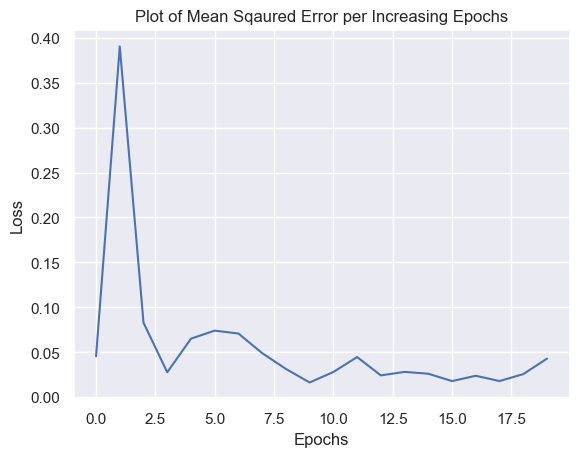

In [51]:
loss= model.history.history['loss']
plt.plot(loss)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Plot of Mean Sqaured Error per Increasing Epochs')

In [52]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_11 (LSTM)                  │ (None, 30, 120)        │        70,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 30, 120)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 30, 170)        │       197,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 30, 170)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 50)             │        44,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 938,075 (3.58 MB)

 Trainable params: 312,691 (1.19 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 625,384 (2.39 MB)

### Testibg the Model Accuracy

In [54]:
## Predicting the test data
test_predict= model.predict(x_test)

## Getting actual test values
test_predict= scaler2.inverse_transform(test_predict)
returnss= scaler2.inverse_transform(y_test)

print('(Predicted)', '(Actual)')

for i in range(len(test_predict)):
    print(test_predict[i], returnss[i])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
(Predicted) (Actual)
[1.0231012] [1.00014347]
[1.0227298] [1.04654655]
[1.0220765] [1.06902087]


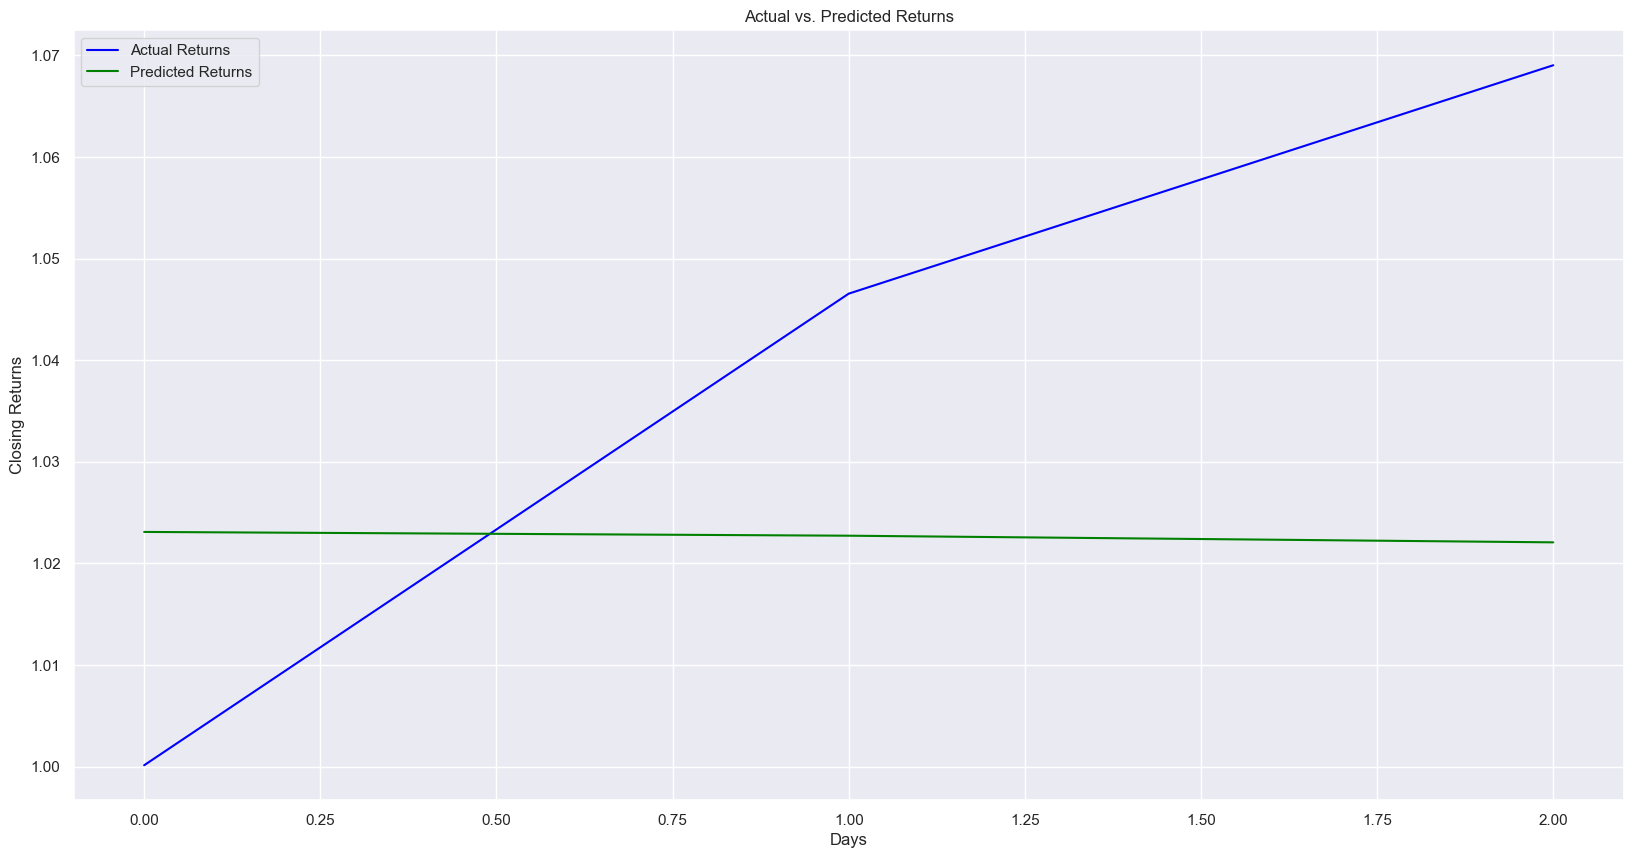

In [57]:
## Plotting the predictions
plt.figure(figsize= (20,10))
plt.plot(returnss, color= 'blue', label= 'Actual Returns')
plt.plot(test_predict[:], color= 'green', label= 'Predicted Returns')

plt.xlabel('Days')
plt.ylabel('Closing Returns')
plt.title('Actual vs. Predicted Returns')
plt.legend()

In [58]:
### Performance Accuracy Evaluation
print('rmse=', math.sqrt(mean_squared_error(returnss, test_predict)))

rmse= 0.033156558364299454


In [59]:
## 30 Days Predictions 
forecasted= test_predict[len(test_predict)-30:]
print(forecasted)

[[1.0231012]
 [1.0227298]
 [1.0220765]]


In [60]:
np.mean(forecasted)

np.float32(1.0226358)